In [254]:
import sys
print("Python Version:",sys.version)
print("Python environment is working!")

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Python environment is working!


# Spam Email Detection Using Machine Learning

## Minor Project

### Objective
Develop a machine learning system that classifies an email/message as Spam or Not Spam based on its content.

### Technologies Used
- Python
- Pandas
- NumPy
- NLTK
- Scikit-learn
- TF-IDF
- Logistic Regression
- Gradio

### Project Workflow
Dataset → Data Cleaning → Text Preprocessing → TF-IDF → Model Training → Model Evaluation → Spam Detection Interface

In [255]:
import pandas as pd
import numpy as np
import sklearn
import nltk

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("NLTK:", nltk.__version__)

Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
NLTK: 3.9.1


In [256]:
import pandas as pd

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 1. Dataset

The dataset contains labeled text messages classified into two categories:

- **Ham (0):** Not Spam
- **Spam (1):** Spam

The dataset contains 5,572 messages and two columns:
- `label`
- `message`

## 2. Exploratory Data Analysis

The dataset was examined to identify:
- Number of records
- Missing values
- Distribution of Spam and Not Spam messages

The dataset contains:
- **4,825 Not Spam messages**
- **747 Spam messages**
- **0 missing values**

The class distribution is visualized using a bar chart.

In [257]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpam vs Ham Count:")
print(df["label"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing Values:
label      0
message    0
dtype: int64

Spam vs Ham Count:
label
ham     4825
spam     747
Name: count, dtype: int64


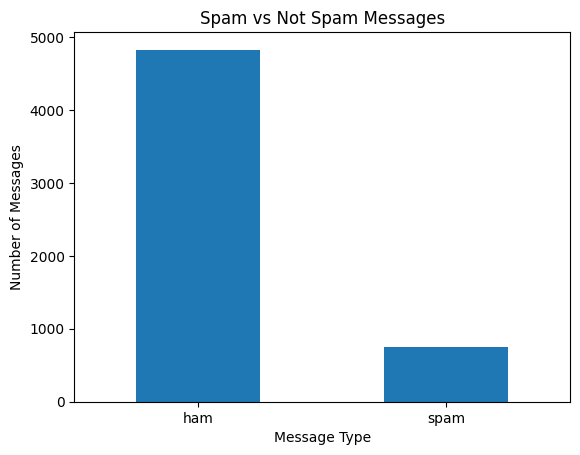

In [258]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Not Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [259]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

print("Labels converted successfully!")
print(df.head())
print("\nLabel counts:")
print(df["label"].value_counts())

Labels converted successfully!
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

Label counts:
label
0    4825
1     747
Name: count, dtype: int64


In [260]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)

print("Text cleaning completed!")
print(df[["message", "clean_message"]].head())

Text cleaning completed!
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in a wkly comp to win fa cup final ...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


## 3. Text Preprocessing

Text preprocessing is performed to convert raw messages into a cleaner form suitable for machine learning.

The following steps are applied:

1. Convert all text to lowercase.
2. Remove URLs.
3. Remove special characters and unnecessary symbols.
4. Remove extra spaces.
5. Remove common English stop words using NLTK.

### Preprocessing Flow

Original Message
↓
Lowercase Conversion
↓
URL Removal
↓
Special Character Removal
↓
Stop-word Removal
↓
Processed Message

In [261]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

print("NLTK resources downloaded successfully!")

NLTK resources downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [262]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["processed_message"] = df["clean_message"].apply(remove_stopwords)

print("Stop-word removal completed!")
print(df[["clean_message", "processed_message"]].head())

Stop-word removal completed!
                                       clean_message  \
0  go until jurong point crazy available only in ...   
1                            ok lar joking wif u oni   
2  free entry in a wkly comp to win fa cup final ...   
3        u dun say so early hor u c already then say   
4  nah i dont think he goes to usf he lives aroun...   

                                   processed_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


In [263]:
X = df["processed_message"]
y = df["label"]

print("Input (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nSample messages:")
print(X.head())

print("\nSample labels:")
print(y.head())

Input (X) shape: (5572,)
Target (y) shape: (5572,)

Sample messages:
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
3                  u dun say early hor u c already say
4          nah dont think goes usf lives around though
Name: processed_message, dtype: object

Sample labels:
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [264]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))
print("Training labels:", len(y_train))
print("Testing labels:", len(y_test))

Training messages: 4457
Testing messages: 1115
Training labels: 4457
Testing labels: 1115


## 4. Feature Extraction Using TF-IDF

Machine learning algorithms cannot directly understand text.

TF-IDF (Term Frequency–Inverse Document Frequency) is used to convert the processed messages into numerical feature vectors.

The TF-IDF vectorizer uses:
- Maximum 5,000 features
- Unigrams and bigrams

The vectorizer is fitted only on the training data and then applied to the test data.

In [265]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization completed!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

TF-IDF vectorization completed!
Training data shape: (4457, 5000)
Testing data shape: (1115, 5000)


## 4. Feature Extraction Using TF-IDF

Machine learning algorithms cannot directly understand text.

TF-IDF (Term Frequency–Inverse Document Frequency) is used to convert the processed messages into numerical feature vectors.

The TF-IDF vectorizer uses:
- Maximum 5,000 features
- Unigrams and bigrams

The vectorizer is fitted only on the training data and then applied to the test data.

In [266]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


## 6. Model Training

Two machine learning algorithms are trained and compared:

### 6.1 Multinomial Naive Bayes

Multinomial Naive Bayes is used as the first baseline model because it is commonly used for text classification.

In [267]:
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred_nb[:20])

print("\nActual labels:")
print(y_test.values[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Actual labels:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Naive Bayes Accuracy: 97.04 %

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
[[966   0]
 [ 33 116]]


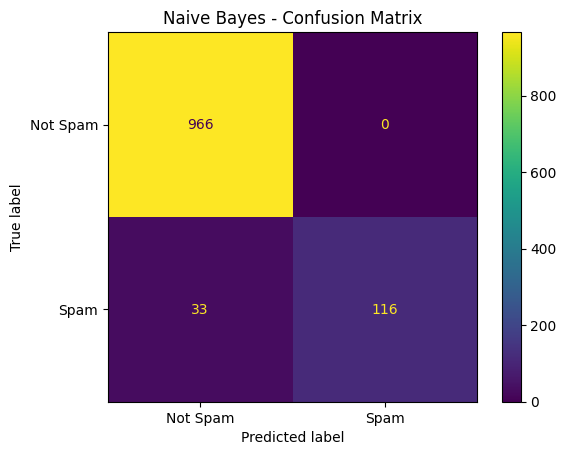

In [268]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(accuracy_nb * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Not Spam", "Spam"]
))

cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm_nb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Not Spam", "Spam"]
).plot()

plt.title("Naive Bayes - Confusion Matrix")
plt.show()

## 7. Model Evaluation

The trained models are evaluated using the following performance metrics:

- **Accuracy:** Measures the overall percentage of correct predictions.
- **Precision:** Measures how many messages predicted as Spam are actually Spam.
- **Recall:** Measures how many actual Spam messages are correctly detected.
- **F1-score:** Provides a balance between Precision and Recall.
- **Confusion Matrix:** Shows the correct and incorrect classifications.

### 7.1 Naive Bayes Evaluation

The Multinomial Naive Bayes model achieved approximately 97% accuracy on the test dataset.

In [269]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### 6.2 Logistic Regression

Logistic Regression is trained as the second classification model.

Class weights are balanced because the dataset contains more Not Spam messages than Spam messages.

The performance of Logistic Regression is then compared with Multinomial Naive Bayes.

In [270]:
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression predictions generated!")
print("First 20 predictions:")
print(y_pred_lr[:20])

print("\nActual labels:")
print(y_test.values[:20])

Logistic Regression predictions generated!
First 20 predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Actual labels:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Logistic Regression Accuracy: 97.67 %

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.99      0.98      0.99       966
        Spam       0.90      0.93      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
[[951  15]
 [ 11 138]]


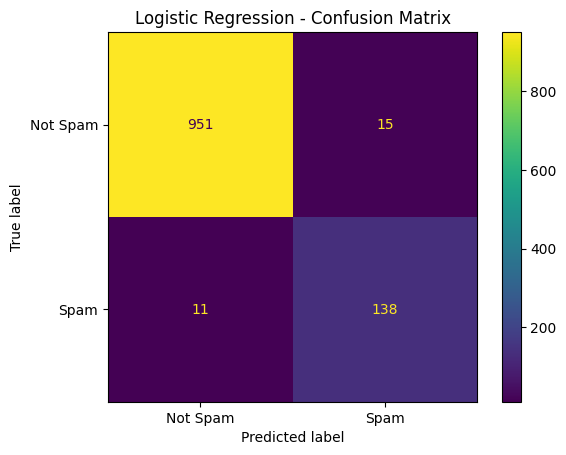

In [271]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(accuracy_lr * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Not Spam", "Spam"]
))

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Not Spam", "Spam"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### 7.2 Logistic Regression Evaluation

Logistic Regression achieved an accuracy of **97.67%** on the test dataset.

The model achieved strong Spam detection performance, with approximately **93% Spam recall**.

The confusion matrix showed:

- 951 Not Spam messages correctly classified
- 15 Not Spam messages incorrectly classified as Spam
- 138 Spam messages correctly classified
- 11 Spam messages incorrectly classified as Not Spam

Based on the comparison, Logistic Regression was selected as the final model because it provided better Spam detection performance than the Naive Bayes baseline.

In [272]:
import joblib

joblib.dump(lr_model, "spam_email_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [273]:
def predict_spam(message):
    cleaned = clean_text(message)
    processed = remove_stopwords(cleaned)
    vectorized = vectorizer.transform([processed])

    prediction = lr_model.predict(vectorized)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "NOT SPAM"


test_message = "Congratulations! You have won a free prize. Click now to claim your reward!"

result = predict_spam(test_message)

print("Message:", test_message)
print("Prediction:", result)

Message: Congratulations! You have won a free prize. Click now to claim your reward!
Prediction: SPAM


## 8. Spam Detection Prediction System

The final Logistic Regression model is used to classify new, unseen messages.

The prediction process follows these steps:

1. Accept a new email or message from the user.
2. Clean the message using the same preprocessing steps.
3. Remove stop words.
4. Convert the processed text into TF-IDF features.
5. Pass the features to the trained Logistic Regression model.
6. Generate the final prediction:
   - **1 → Spam**
   - **0 → Not Spam**

In [274]:
test_messages = [
    "Congratulations! You have won a free prize. Click now to claim your reward!",
    "Hi, are we meeting tomorrow at 10 AM? Please bring the project files."
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_spam(message))
    print("-" * 60)

Message: Congratulations! You have won a free prize. Click now to claim your reward!
Prediction: SPAM
------------------------------------------------------------
Message: Hi, are we meeting tomorrow at 10 AM? Please bring the project files.
Prediction: NOT SPAM
------------------------------------------------------------


In [275]:
!pip install -q gradio

In [276]:
import gradio as gr

def check_email(message):
    if not message.strip():
        return "⚠️ Please enter an email or message."

    result = predict_spam(message)

    if result == "SPAM":
        return "🚨 SPAM EMAIL DETECTED"
    else:
        return "✅ NOT SPAM — This appears to be a normal message"


demo = gr.Interface(
    fn=check_email,
    inputs=gr.Textbox(
        lines=8,
        placeholder="Paste your email or message here...",
        label="Email / Message"
    ),
    outputs=gr.Textbox(
        label="Detection Result"
    ),
    title="📧 Spam Email Detection System",
    description="Enter an email or message to check whether it is Spam or Not Spam.",
    submit_btn="Check Email",
    clear_btn="Clear"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4fc0d75cc19d5c6ac6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. User Interface

A simple web-based interface is developed using Gradio.

The interface allows the user to:

- Enter or paste an email/message.
- Click the **Check Email** button.
- Receive the classification result.
- Clear the input and test another message.

The system displays either:

**SPAM EMAIL DETECTED**

or

**NOT SPAM — This appears to be a normal message**

## 10. Final Results

The Spam Email Detection system was successfully developed using Natural Language Processing and Machine Learning techniques.

### Final Model Performance

| Model | Accuracy | Spam Recall |
|---|---:|---:|
| Multinomial Naive Bayes | ~97% | ~78% |
| Logistic Regression | **97.67%** | **93%** |

Logistic Regression was selected as the final model because it provided stronger Spam detection performance.

### Final System

The completed system can:

- Accept a new email/message.
- Preprocess the text.
- Convert the text into TF-IDF numerical features.
- Classify the message using Logistic Regression.
- Display the result as Spam or Not Spam.

## 11. Conclusion

The project demonstrates how Natural Language Processing and Machine Learning can be used to automatically detect spam messages.

The final system achieved **97.67% accuracy** on the test dataset and successfully classified new messages through the user interface.

The project provides a practical foundation for automated spam detection and can be further improved using larger datasets, additional machine learning algorithms, and more advanced NLP techniques.